# 03-2 잘못된 데이터 수정하기

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://nbviewer.jupyter.org/github/rickiepark/hg-da/blob/main/03-2.ipynb"><img src="https://jupyter.org/assets/share.png" width="61" />주피터 노트북 뷰어로 보기</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/rickiepark/hg-da/blob/main/03-2.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />구글 코랩(Colab)에서 실행하기</a>
  </td>
</table>

## 데이터프레임 정보 요약 확인하기

수집된 데이터에서 누락된 값이나 잘못된 값을 다루는 방법을 알아보자.
데이터에서 잘못된 값을 파악하려면 데이터가 의미하는 바를 이해하고 시간을 들여 직접 데이터를 꼼꼼하게 살펴보아야 한다. 따라서 판다스 데이터프레임의 데이터를 조작하는 다양한 방법을 소개한다.

In [23]:
import gdown

gdown.download('https://bit.ly/3GisL6J', 'ns_book4.csv', quiet=False)

Downloading...
From: https://bit.ly/3GisL6J
To: /content/ns_book4.csv
100%|██████████| 55.5M/55.5M [00:01<00:00, 52.6MB/s]


'ns_book4.csv'

앞서 불필요한 행과 열을 삭제하는 방법을 배웠다.
그런데 이번에는 데이터가 군데 군대 비어 있다고 하네요.
판다스는 누락된 값을 기본적으로 **NaN**으로 표시한다.
이번 절에서는 **NaN**을 확인하는 방법을 알아봅니다.
그리고**NaN**을 채우는 여러 가지 방법을 소개합니다.
수집한 남산도서관 대출 데이터에서 **NaN**을 찾아 수정하고 다른 데이터 세트에서도 반복해서 적용할 수 있도록 수행한작업을 하나의 파일썬 함수로 만들어 보겠습니다.

In [24]:
import pandas as pd

ns_book4 = pd.read_csv('ns_book4.csv', low_memory=False)
ns_book4.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0.0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0.0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0.0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0.0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0.0,2021-03-19


처음 다섯 개 행에서 NaN으로 표시된 열이 여러 개 보인다. info()메서드를 사용하면 열마다 NaN이 아닌 값이 몇개나 있는지 확인할 수 있다.

In [25]:
ns_book4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384591 entries, 0 to 384590
Data columns (total 13 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   번호       384591 non-null  int64  
 1   도서명      384188 non-null  object 
 2   저자       384393 non-null  object 
 3   출판사      379950 non-null  object 
 4   발행년도     384577 non-null  object 
 5   ISBN     384591 non-null  object 
 6   세트 ISBN  56576 non-null   object 
 7   부가기호     310386 non-null  object 
 8   권        63378 non-null   object 
 9   주제분류번호   364727 non-null  object 
 10  도서권수     384591 non-null  int64  
 11  대출건수     384591 non-null  float64
 12  등록일자     384591 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 38.1+ MB


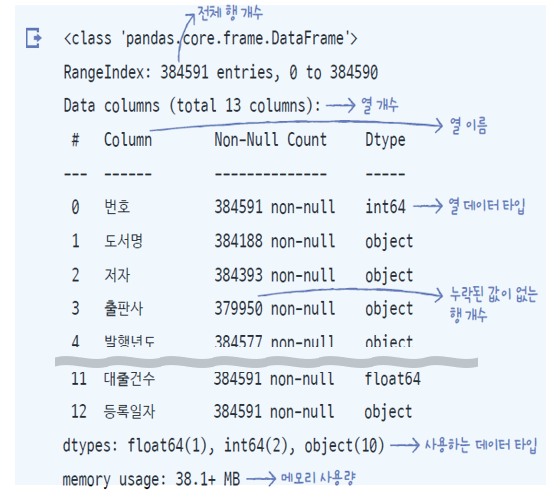

info()메서드는 기본적으로 원소 개수와 열 데이터 타입을 기반으로 메모리 사용량을 추정합니다. **정확한 메모리 사용량을 얻으려면 memory_usage매개변수에 'deep'옵션을 지정합니다.**

In [26]:
ns_book4.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384591 entries, 0 to 384590
Data columns (total 13 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   번호       384591 non-null  int64  
 1   도서명      384188 non-null  object 
 2   저자       384393 non-null  object 
 3   출판사      379950 non-null  object 
 4   발행년도     384577 non-null  object 
 5   ISBN     384591 non-null  object 
 6   세트 ISBN  56576 non-null   object 
 7   부가기호     310386 non-null  object 
 8   권        63378 non-null   object 
 9   주제분류번호   364727 non-null  object 
 10  도서권수     384591 non-null  int64  
 11  대출건수     384591 non-null  float64
 12  등록일자     384591 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 234.0 MB


ns_book4데이터프레임의 메모리 사용량이 200MB가 넘는다는 것을 확인할 수 있습니다.

## 누락된 값 처리하기

데이터프레임에 누락된 값이 있다는 것을 대략 확인하였으니 정확한 데이터 분석을 위해 누락된 값을 다루는 방법을 자세히 알아보자. 각열의 누락된 값이 정확하게 몇 개가 있는지 확인하고, **누락된 값을 표시하는 방법을 표시하는 방법을 알아보자. 그리고 누락된 값을 다른 값으로 바꾸어 보자.**

info()메서드로 출력한 값으로 누락된 값이 있는 행 개수를 헤아릴 수 있지만 조금 번거롭습니다. 대신 NaN을 직접 카운트할 수 있는 isna()메서드를 사용하면 훨씬 편리합니다. isna()메서드는 각 행이 비어 있는지를 나타내는 불리언 배열을 반환합니다. 그리고 sum()메서드를 이어서 호출하면 불리언 배열의 True개수로 비어 있는 행 개수를 얻을 수 있다.

In [27]:
ns_book4.isna().sum()

,0
번호,0
도서명,403
저자,198
출판사,4641
발행년도,14
ISBN,0
세트 ISBN,328015
부가기호,74205
권,321213
주제분류번호,19864


열 데이터 타입은 int64로 64비트 정수를 저장할 수 있습니다.
실행결과를 보니 '도서권수' 열은 누락된 값이 하나도 없네요.
isna()메서드와 반대로 누락되지 않은 값을 확인할 때는 notna()메서드를 사용합니다.

###누락된 값으로 표시하기:None과 np.nan

---

이번에는 임의로 누락된 값을 만든 후 NaN으로 표시하는 방법을 알아보자. 판다스 데이터프레임에서는 정수를 저장하는 열에 파이썬의 Nonne을 입력하면 누락된 값으로 인식합니다.

ns_book4데이터프레임의 '도서권수'열에 있는 첫 번째 행 값을 None으로 바꾼 후'도서권수'열에 isna()메서드를 적용해 누락된 값을 세어 보겠습니다.

In [28]:
ns_book4.loc[0, '도서권수'] = None
ns_book4['도서권수'].isna().sum()

np.int64(1)

head()메서드로 처음 두 개의 행을 출력하여 첫 번째 행의 '도서권수' 값이 어떻게 바뀌었는지 확인

In [29]:
ns_book4.head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,NaN,0.0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1.0,0.0,2021-03-19


NaN이 출력된다. 그런데 두 번째 행의 '도서권수'값이 1이었는데 1.0으로 바뀌었다. 이는 판다스가 NaN을 특별한 실수 값으로 저장하기 때문이다. 그래서 원래 데이터타입이 int64였던 '도서권수'열이 NaN을 표시하기 위해 float64로 자동 변환!


'도서권수'열의 첫번째 행을 원래대로 1로 바꾸어 보겠다. 현재 데이터 타입이 실수형이므로 다시 정수형으로 바꾸어야 한다. 이때 '도서권수'열과 함께 '대출건수ㅜ'열도 데이터타입을 int64로 바꾸어보자. 데이터타입을 지정할 때는 astype()메서드를 사용한다.** 매개변수를 {열 이름:데이터 타입}형식의 딕셔너리로 전달!**

In [30]:
ns_book4.loc[0, '도서권수'] = 1
ns_book4 = ns_book4.astype({'도서권수':'int32', '대출건수': 'int32'})
ns_book4.head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19


정수형이 아니라 문자열을 저장할 수 있는 열에 None을 입력하면 어떨까요? 데이터 타입이 object인 '부가기호'열의 첫 번째 행에 None을 입력해 보자.

In [31]:
ns_book4.loc[0, '부가기호'] = None
ns_book4.head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,None,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19


정수형 열에 입력했을 때처럼 NaN으로 표시되지 않고 문자열 그대로 None으로 표시됩니다. 그럼 None대신에 NaN을 입랙해야 할까요?

사실 판다스는 NaN이라는 값을 따로 가지고 있지 않습니다. 대신 넘파이 패키지에 있는 np.nan을 사용해야 합니다. 따라서 첫 번째 행의 '부가기호'열의 값을 None에서 NaN으로 표시하려면 다음과 같이np.nan을 사용합니다.

In [32]:
import numpy as np

ns_book4.loc[0, '부가기호'] = np.nan
ns_book4.head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19


지금까지 누락된 값을 표시하는 NaN에 대해 알아보았습니다. 처음NaN을 만나면 어리둥절하고 이해하기 어려울 수 있지만 다양하게 NaN을 다루었기 때문에 조금 친숙해졌을 것이라고 생각합니다.

##누락된 값 바꾸기(1):loc,fillna()메서드

---



'세트ISBN'열은 대부분의 값이 비어 있습니다. 이누락된 값을 NaN이 아니라 빈 문자열('')로 바꾸어 보겠습니다.

loc메서드를 사용하면 누락된 값을 원하는 값으로 바꿀 수 있습니다.
그러려면 누락된 값을 가리키는 불리언 배열을 만들어야 하는데, 누락된 값을 확인하는 isna()메서드로 간단하게 만들 수 있습니다.

isna()메서드로 '세트ISBN'열의 NaN을 가리키는 set_isbn_na_rows 불리언 배열을 만들고, loc메서드에 전달합니다.

In [33]:
set_isbn_na_rows = ns_book4['세트 ISBN'].isna()
ns_book4.loc[set_isbn_na_rows, '세트 ISBN'] = ''

ns_book4['세트 ISBN'].isna().sum()

np.int64(0)

'세트ISBN'열의 NaN을 모두 빈 문자열로 바꾸었기 때문에 누락된 행의 개수는 0 입니다.

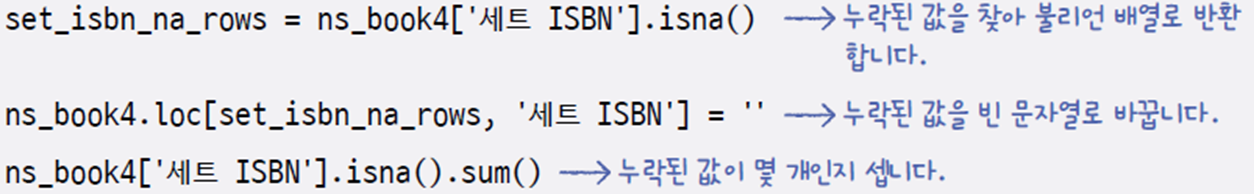

이처럼loc메서드로 NaN을 다른 값으로 바꿀 수 있지만, 조금 더 편리한 방법은 fillna()메서드입니다. fillna()메서드에 원하는 값을 전달하면 NaN을 대체할 수 있습니다.

ns_book4에 있는 모든 NaN을 '없음'문자열로 바꾸어 보겠습니다. fillna()메서드는 기본적으로 새로운 데이터프레임을 반환하므로 fillna()메서드에 이어서 isna()메서드를 연결하면 NaN의 개수를 셀 수 있습니다.

In [34]:
ns_book4.fillna('없음').isna().sum()

,0
번호,0
도서명,0
저자,0
출판사,0
발행년도,0
ISBN,0
세트 ISBN,0
부가기호,0
권,0
주제분류번호,0


NaN이 모두 '없음'문자열로 바뀌어 NaN개수를 세면 0이 출력됩니다.
물론 다음 코드처럼 특정 열만 선택해서 NaN을 바꿀 수도 있습니다.

In [35]:
ns_book4['부가기호'].fillna('없음').isna().sum()

np.int64(0)

하지만 특정 열을 선택한 후 fillna()메서드를 적용하면 앞의 실행 결과처럼 열 이름 없이 개수만 있는 판다스 시리즈 객체로 반환합니다.

'부가기호'열의 NaN을 바꾸면서 전체 데이터프레임을 반환하려면 다음처럼 열 이름과 바꾸려는 값으로 이루어진 딕셔너리를 전달하면 됩니다.

In [36]:
ns_book4.fillna({'부가기호':'없음'}).isna().sum()

,0
번호,0
도서명,403
저자,198
출판사,4641
발행년도,14
ISBN,0
세트 ISBN,0
부가기호,0
권,321213
주제분류번호,19864


##누락된 값 바꾸기(2):replace()메서드

---



replace()메서드는 NaN은 물론 어떤 값도 바꿀 수 있는 편리한 메서드입니다.
replace()메서드는 사용법이 다양하므로 손코딩을 해 보며 하나씩 알아보겠습니다.

##첫째, 바꾸려는 값이 하니일 때

바꾸려는 값이 하나라면 replace()메서드의 첫 번째 매개변수에는 원래 값을, 두 번째 매개변수에는새로운 값을 전달합니다.
replace(원래 값, 새로운 값)

원래 값에 np.nan을 전달하여 NaN을 '없음'으로 바꿔 보겠습니다.

In [37]:
ns_book4.replace(np.nan, '없음').isna().sum()

,0
번호,0
도서명,0
저자,0
출판사,0
발행년도,0
ISBN,0
세트 ISBN,0
부가기호,0
권,0
주제분류번호,0


##둘째, 바꾸려는 값이 여러 개일 때

바꾸려는 값이 여러 개일 때는 리스트 형식으로 전달합니다.
replace([원래 값1,원래 값2],[새로운 값1, 새로운 값2])

NaN을 '없음'으로 바꾸고 '2021'문자열을 '21'로 바꾸면 다음과 같습니다.

In [42]:
ns_book4.replace([np.nan, '2021'], ['없음', '21']).head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,21,9788937444319,,없음,없음,없음,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,21,9791190123969,,없음,없음,없음,1,0,2021-03-19


또는 리스트 대신({원래 값1:새로운 값1, 원래 값2:새로운 값2})처럼 딕셔너리 형식으로도 전달할 수 있습니다.

In [43]:
ns_book4.replace({np.nan: '없음', '2021': '21'}).head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,21,9788937444319,,없음,없음,없음,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,21,9791190123969,,없음,없음,없음,1,0,2021-03-19


##셋째, 열 마다 다른 값으로 바꿀 때

열 이름과 바꾸려는 값을 딕셔너리 형식으로 전달하여 열마다 다른 값을 바꿀 수 있습니다.

replace({열 이름: 원래 값},새로운 값)

'부가기호'열의 NaN을 '없음'으로 바꾸면 다음과 같습니다.

In [46]:
ns_book4.replace({'부가기호': np.nan}, '없음').head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,,없음,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,,없음,NaN,NaN,1,0,2021-03-19


또는 열 이름과 변경 전후의 값을 ({열 이름:{원래 값1:새로운 값1}})과 같이 중첩된 딕셔너리로 전달할 수 있습니다. '부가기호'열의 NaN을 '없음'으로 바꾸고 '발행년도'열의'2021'을 '21'로 바꾸면 다음과 같습니다.

In [47]:
ns_book4.replace({'부가기호': {np.nan: '없음'}, '발행년도': {'2021': '21'}}).head(2)

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,21,9788937444319,,없음,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,21,9791190123969,,없음,NaN,NaN,1,0,2021-03-19


지금까지 fillna()메서드와 replace()메서드를 사용하여 누락된 값을 바꾸는 다양한 방법을 알아보았습니다. 마지막으로 replace()메서드와 정규 표현식을 사용하는 방법을 알아보겠습니다.

## 정규 표현식

정규표현식 또는 줄여서 정규식은 문자열 패턴을 찾아서 대체하기 위한 규칙의 모임입니다. replace()메서드로 인덱스 100번과 101번 행의 네 자리 연구('2021')를 주 자리('21')로 바꾸어 보면 다음과 같습니다.

이때 연도가 다르면 문제가 됩니다. 연도가 '2021'일 경우 '21'로 바뀌지만 '2018'은 적용이 되지 않습니다.

In [49]:
ns_book4.replace({'발행년도': {'2021': '21'}})[100:102]

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
100,101,No라고 말할 줄 아는 남편과 아내 - 개정판,"헨리 클라우드, 존 타운센드 (지은이), 김진웅 (옮긴이)",좋은씨앗,2018,9788958743019,,NaN,NaN,234.9,1,1,2021-03-15
101,102,"D2C 레볼루션 - 스타트업부터 글로벌 기업까지, 마켓 체인저의 필수 전략","로런스 인그래시아 (지은이), 안기순 (옮긴이)",부키,21,9788960518483,,NaN,NaN,325.1,1,0,2021-03-15


물론 replace()메서드에 '2018'을 '18'로 바꾸도록 추가할 수 있습니다. 하지만 도서 발행 연도는 범위가 넓기 때문에 이런 식으로 일일이 모두 기재하여 바꾸는 것은 번거롭습니다. 이럴 때 정규 표현식을 사용하면 훨씬 간편하게 이런 작업을 수행할 수 있다.

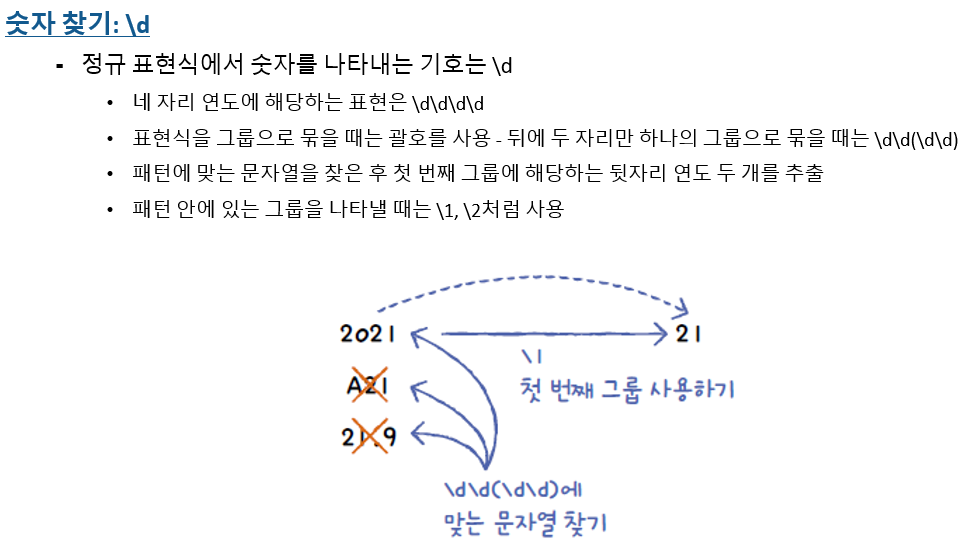

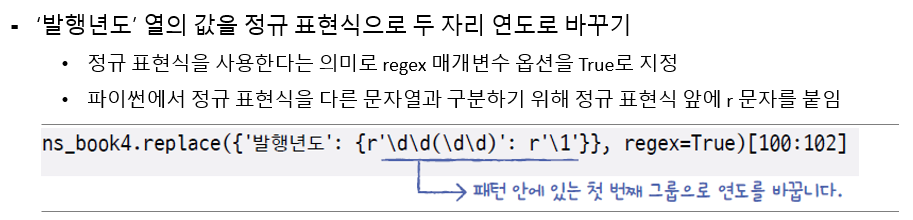

In [55]:
ns_book4.replace({'발행년도': {r'(\d\d)(\d\d)': r'\2'}}, regex=True)[100:102]

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
100,101,No라고 말할 줄 아는 남편과 아내 - 개정판,"헨리 클라우드, 존 타운센드 (지은이), 김진웅 (옮긴이)",좋은씨앗,18,9788958743019,,NaN,NaN,234.9,1,1,2021-03-15
101,102,"D2C 레볼루션 - 스타트업부터 글로벌 기업까지, 마켓 체인저의 필수 전략","로런스 인그래시아 (지은이), 안기순 (옮긴이)",부키,21,9788960518483,,NaN,NaN,325.1,1,0,2021-03-15


이떼 정규 표현식 앞에 붙인 r문자는 원시문자열raw string을 만듭니다.

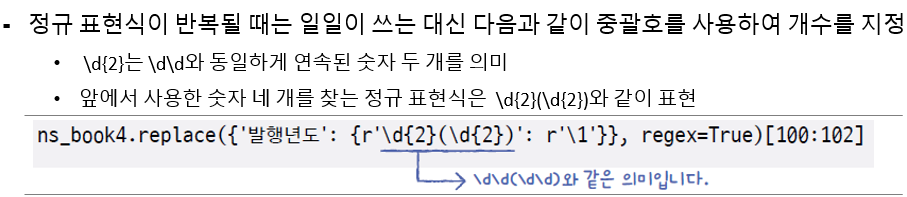

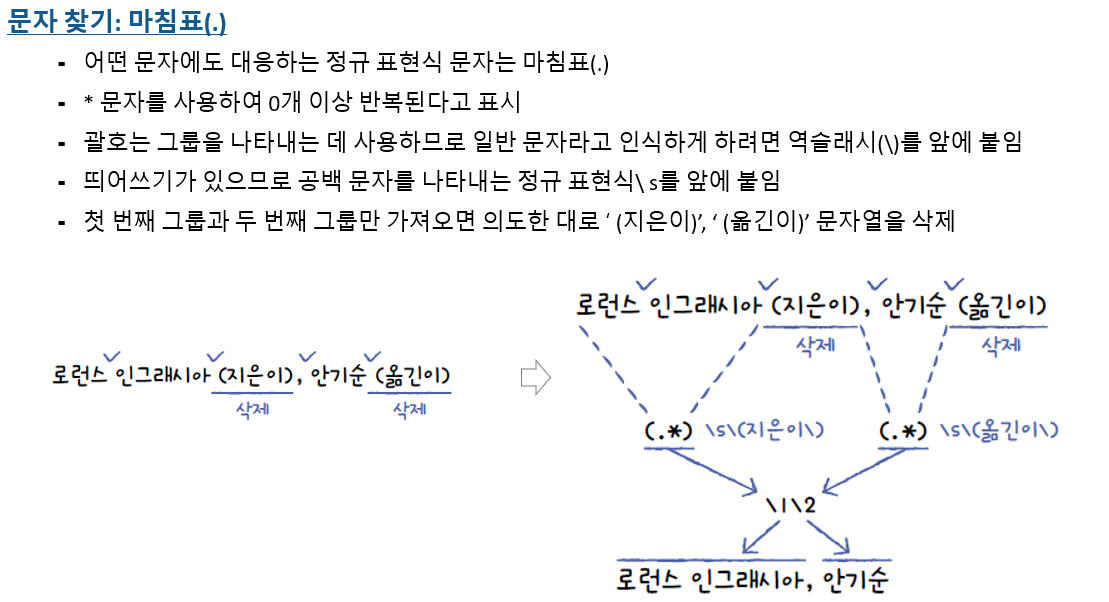

In [58]:
ns_book4.replace({'발행년도': {r'(\d{2})(\d{2})': r'\1'}}, regex=True)[100:102]

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
100,101,No라고 말할 줄 아는 남편과 아내 - 개정판,"헨리 클라우드, 존 타운센드 (지은이), 김진웅 (옮긴이)",좋은씨앗,20,9788958743019,,NaN,NaN,234.9,1,1,2021-03-15
101,102,"D2C 레볼루션 - 스타트업부터 글로벌 기업까지, 마켓 체인저의 필수 전략","로런스 인그래시아 (지은이), 안기순 (옮긴이)",부키,20,9788960518483,,NaN,NaN,325.1,1,0,2021-03-15


In [59]:
ns_book4.replace({'저자': {r'(.*)\s\(지은이\)(.*)\s\(옮긴이\)': r'\1\2'},
                  '발행년도': {r'\d{2}(\d{2})': r'\1'}}, regex=True)[100:102]

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
100,101,No라고 말할 줄 아는 남편과 아내 - 개정판,"헨리 클라우드, 존 타운센드, 김진웅",좋은씨앗,18,9788958743019,,NaN,NaN,234.9,1,1,2021-03-15
101,102,"D2C 레볼루션 - 스타트업부터 글로벌 기업까지, 마켓 체인저의 필수 전략","로런스 인그래시아, 안기순",부키,21,9788960518483,,NaN,NaN,325.1,1,0,2021-03-15


## 잘못된 값 바꾸기

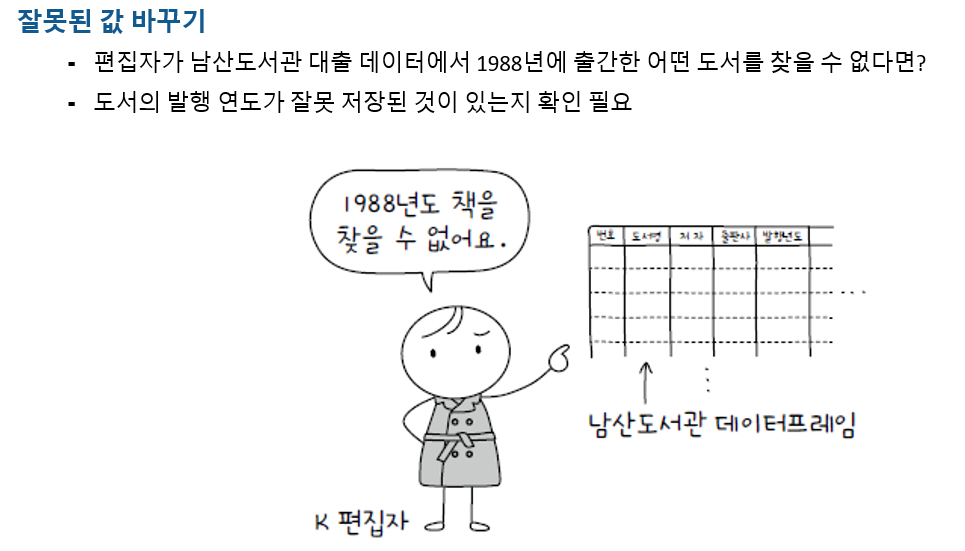

먼저 데이터 타입을 지정해 보겠습니다. astype()메서드로 '발행년도'열을 int64로 바꾸어보니 오류가 발생합니다.

In [62]:
# 아래 코드는 오류 발생
ns_book4.astype({'발행년도': 'int32'})

ValueError: invalid literal for int() with base 10: '1988.': Error while type casting for column '발행년도'

'1988'이라는 연도를 변환할 수 없어 오류가 발생했습니다. 아무래도 숫자가 아닌 다른 문자가 들어 있는 것 같습니다. 정규표현식으로 다른 문자가 있는 연도를 찾아보겠습니다.

판다스 시리즈 객체는 str속성 아래 다양한 문자열 처리 함수를 제공합니다. 그중contain()메서드는 시리즈나 인덱스에서 문자열 패턴을 포함하고 있는지 검사합니다. '발행년도'열에 '1988'이 포함된 행의 개수를 세어 보겠습니다.

In [60]:
ns_book4['발행년도'].str.contains('1988').sum()

407

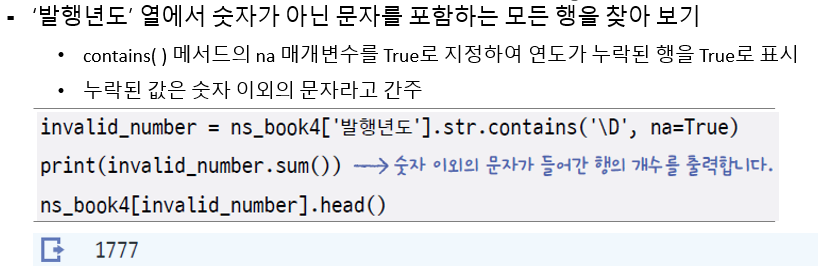

In [64]:
invalid_number = ns_book4['발행년도'].str.contains('\D', na=True)
print(invalid_number.sum())
ns_book4[invalid_number].head()

1777


<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_25590/1631807378.py:1: SyntaxWarning: invalid escape sequence '\D'
  invalid_number = ns_book4['발행년도'].str.contains('\D', na=True)


,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
19138,19565,단국강토,홍태수 저,매일경제신문사,1988.,9788974420031,,NaN,NaN,511.1,1,1,2019-12-19
19227,19736,삼성의 역사,송부웅 撰,삼양,단기4334[2001],9788985464369,,0,NaN,911.02,1,1,2019-12-06
26097,26812,배고픈 애벌레,에릭 칼 글·그림 ;이희재 옮김,더큰컴퍼니,[2019],9788959514083,,NaN,NaN,843,1,0,2019-08-12
29817,30586,(The) Sopranos sessions,"Matt Zoller Seitz,$eAlan Sepinwall,$eLaura Lip...",Harry N Abrams Inc,2019.,9781419734946,,NaN,NaN,326.76,1,0,2019-06-13
29940,30709,다음엔 너야,에른스트 얀들 글;노르만 융에 그림;박상순 옮김,비룡소,2018.,9788949110646,9788949110004,7,NaN,853,1,9,2019-06-04


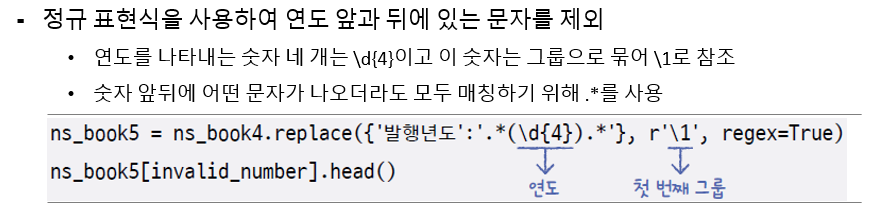

In [66]:
ns_book5 = ns_book4.replace({'발행년도':r'.*(\d{4}).*'}, r'\1', regex=True)
ns_book5[invalid_number].head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
19138,19565,단국강토,홍태수 저,매일경제신문사,1988,9788974420031,,NaN,NaN,511.1,1,1,2019-12-19
19227,19736,삼성의 역사,송부웅 撰,삼양,2001,9788985464369,,0,NaN,911.02,1,1,2019-12-06
26097,26812,배고픈 애벌레,에릭 칼 글·그림 ;이희재 옮김,더큰컴퍼니,2019,9788959514083,,NaN,NaN,843,1,0,2019-08-12
29817,30586,(The) Sopranos sessions,"Matt Zoller Seitz,$eAlan Sepinwall,$eLaura Lip...",Harry N Abrams Inc,2019,9781419734946,,NaN,NaN,326.76,1,0,2019-06-13
29940,30709,다음엔 너야,에른스트 얀들 글;노르만 융에 그림;박상순 옮김,비룡소,2018,9788949110646,9788949110004,7,NaN,853,1,9,2019-06-04


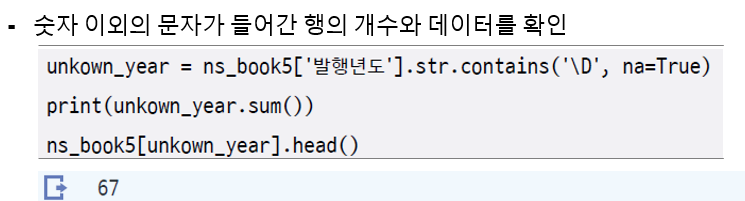

In [67]:
unkown_year = ns_book5['발행년도'].str.contains('\D', na=True)
print(unkown_year.sum())
ns_book5[unkown_year].head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_25590/2094730826.py:1: SyntaxWarning: invalid escape sequence '\D'
  unkown_year = ns_book5['발행년도'].str.contains('\D', na=True)


67


,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
30838,31616,본격 한중일 세계사 5,굽시니스트 지음,위즈덤하우스,NaN,9791190065092,,NaN,NaN,NaN,0,0,2019-05-28
39130,40141,정책금융의 현황과 발전과제,정책금융연구회,한국산업은행,NaN,9788992784108,,NaN,NaN,327.1,1,0,2019-01-22
39256,40268,서울지역 유적 발굴조사 총서 3,서울역사박물관,서울역사박물관,NaN,9791186324714,9791186324431,NaN,NaN,NaN,0,0,2019-01-22
76836,81202,흰머리 큰줄기,한호진 지음,秀文出版社,[발행년불명],9788973010769,,0,NaN,699.1,1,1,2016-11-10
150543,160436,(속) 경제학사,박장환 지음,NaN,[20--],9788994339207,,1,NaN,320.9,1,2,2012-11-19


1,777개에서 67개로 줄였군요! 이제 변환되지 않은 값은 NaN이거나 네 자리 숫자가 아닌 값입니다. 이런 값은 어떻게 변환할지 알 수 없기 때문에 임의로 -1값으로 바꾼다음 astype()메서드로 '발행년도'열의 데이터 타입을 정수형인 int64로변환합니다.

In [68]:
ns_book5.loc[unkown_year, '발행년도'] = '-1'
ns_book5 = ns_book5.astype({'발행년도': 'int32'})

이게 끝이 아닙니다. 연도 중에 이상하게 아주 큰 값이나 작은 값이 들어 있는 경우가 있습니다. 먼저 연도가 4000년이 넘는 경우를 확인해보죠!

gt()메서드는 전달된 값보다 큰 값을 찾습니다. 연도가 4000년이 넘는 행의 전체 개수를 확인하기 위해 sum()함수를 함께 사용합니다.

In [69]:
ns_book5['발행년도'].gt(4000).sum()

np.int64(131)

4000년이 넘는 경우가 131권이나 됩니다. 아마도 단군기원을 사용한 것 같습니다.

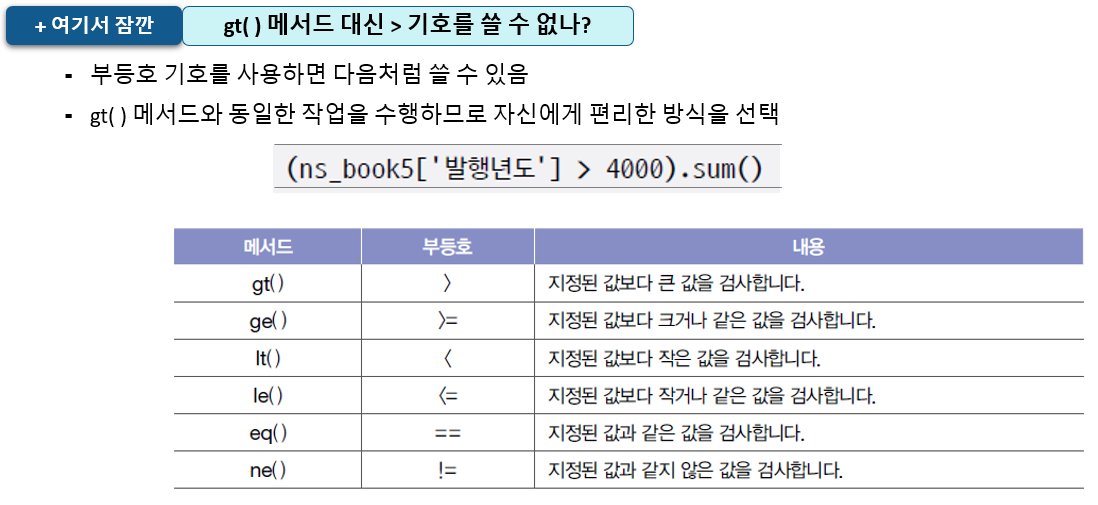

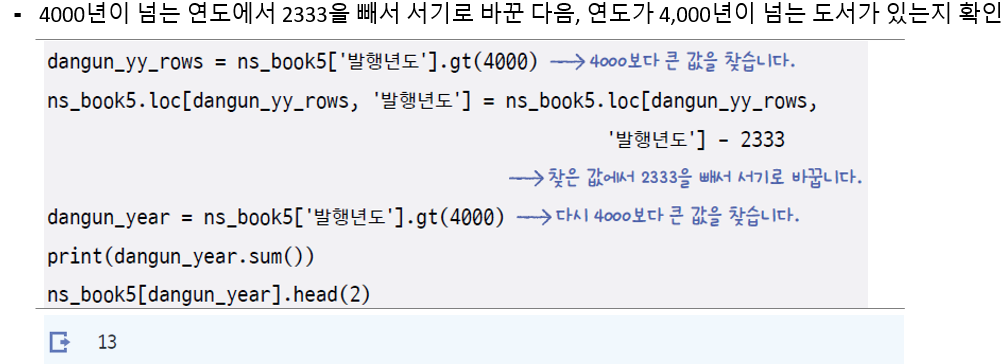

In [70]:
dangun_yy_rows = ns_book5['발행년도'].gt(4000)
ns_book5.loc[dangun_yy_rows, '발행년도'] = ns_book5.loc[dangun_yy_rows, '발행년도'] - 2333

In [72]:
dangun_year = ns_book5['발행년도'].gt(4000)
print(dangun_year.sum())
ns_book5[dangun_year].head(2)

13


,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
222858,234268,Modern art,[computer file],GROLIER,7611,9780717233243,,NaN,NaN,609.205,1,1,2009-05-07
270269,282852,현대 영어학=Linguistic theory in modern english,이재영,열림기획,7634,9788986705072,,1,NaN,740.1,1,6,2007-04-14


연도가 이상하게 높은 도서가 13권이나 되네요. 이런 도서는 모두 -1로 표시합니다.

In [73]:
ns_book5.loc[dangun_year, '발행년도'] = -1

마지막으로 연독 ㅏ작은 값도 확인해야 합니다. 이번에는 0보다 크고 1900년도 이전의 도사를 찾아보죠.

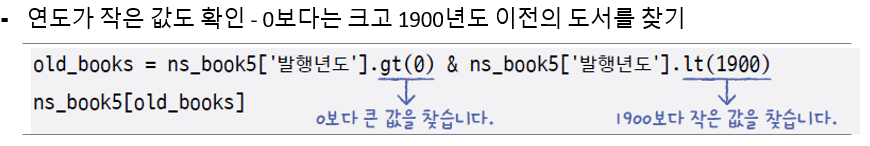

In [74]:
old_books = ns_book5['발행년도'].gt(0) & ns_book5['발행년도'].lt(1900)
ns_book5[old_books]

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
61149,64093,"고흐 씨, 시 읽어 줄까요 :내 마음을 알아주는 시와 그림의 만남",이운진 지음,사계절,176,9788958284277,,0,NaN,811.7,1,6,2017-10-27
70566,74347,정신 병리학의 문제들,지은이: 지그문트 프로이트 ;옮긴이: 황보석,열린책들,151,9788932905181,9788932905082,9,10,185.5,1,4,2017-04-26
79550,84164,(최근 7년간) 중요 민법판례 :[2009년 1월~2016년 6월 중요 판례],이광섭 편저,법학사,163,9788962898651,,9,NaN,365,1,14,2016-09-27
147950,157759,(한·중·일) 밥상 문화 :대표음식으로 본 3국 문화비교,김경은 지음,이가서,132,9788958643012,,0,NaN,381.75,1,30,2013-02-19
194576,205407,책으로 뒤덮인 집의 비밀,N.E. 보드 지음 ;피터 퍼거슨 그림 ;김지현 옮김,개암나무,1015,9788992844413,,7,NaN,843,1,15,2010-08-18
287252,300283,(밝혀질)우리歷史,吳在城 著,黎民族史硏究會,1607,9788986892130,,0,NaN,911,1,5,2006-07-06


여전히 잘못된 값이 있네요. 이도서도 연도를 -1로 설정하고 전체 행 개수를 확인해 보죠.

In [ ]:
ns_book5.loc[old_books, '발행년도'] = -1

In [75]:
ns_book5['발행년도'].eq(-1).sum()

np.int64(80)

## 누락된 정보 채우기

혼공분석은 남산 도서관 대출 데이터에서 '도서명','저자','출판사','발행년도'열이 분석에 중요하다고 판단했습니다. 따라서 이 4개 열에는 누락된 값이 있으면 안됩니다. 먼저 '도서명','저자','출판사'열에 누락된 값이 있거나 '발행년도'열이 -1인 행의 개수를 확인해보겠습니다.

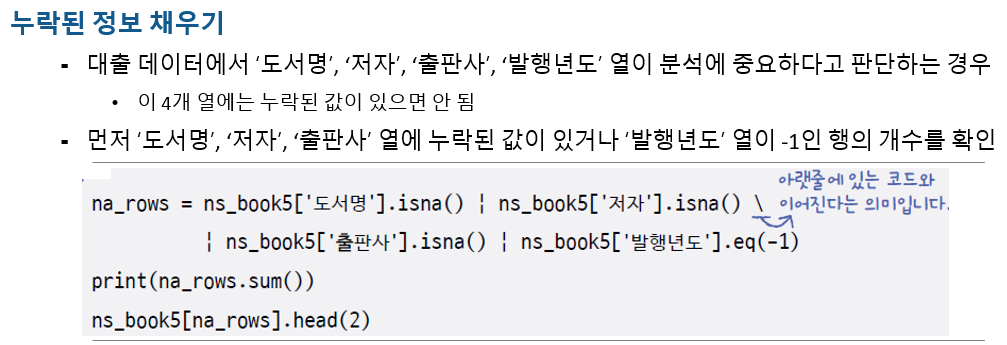

In [76]:
na_rows = ns_book5['도서명'].isna() | ns_book5['저자'].isna() \
          | ns_book5['출판사'].isna() | ns_book5['발행년도'].eq(-1)
print(na_rows.sum())
ns_book5[na_rows].head(2)

5262


,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
78,79,아산 정주영 레거시,김화진,NaN,2021,9788952129529,,NaN,NaN,325,1,1,2021-03-15
265,278,골목의 시간을 그리다,정명섭.김효찬 지음,NaN,2021,9791191266054,,NaN,NaN,NaN,1,0,2021-03-12


값이 누락되었거나 알 수 없는 행이 5262개 입니다. 뷰티플수프를 사용해 이런 값을 채워 보겠습니다. 먼저 requests패키지와 bs4패키지를 임포트 합니다.

In [95]:
# DH_KEY_TOO_SMALL 에러가 발생하는 경우 다음 코드의 주석을 제거하고 실행하세요.
# https://stackoverflow.com/questions/38015537/python-requests-exceptions-sslerror-dh-key-too-small
# import requests

# requests.packages.urllib3.util.ssl_.DEFAULT_CIPHERS += 'HIGH:!DH:!aNULL'
# try:
#     requests.packages.urllib3.contrib.pyopenssl.DEFAULT_SSL_CIPHER_LIST += 'HIGH:!DH:!aNULL'
# except AttributeError:
#     # no pyopenssl support used / needed / available
#     pass

In [91]:
import requests
from bs4 import BeautifulSoup

In [93]:
def get_book_title(isbn):
    # Yes24 도서 검색 페이지 URL
    url = 'http://www.yes24.com/Product/Search?domain=BOOK&query={}'
    # URL에 ISBN을 넣어 HTML 가져옵니다.
    r = requests.get(url.format(isbn))
    soup = BeautifulSoup(r.text, 'html.parser')   # HTML 파싱
    # 클래스 이름이 'gd_name'인 a 태그의 텍스트를 가져옵니다.
    title = soup.find('a', attrs={'class':'gd_name'}) \
            .get_text()
    return title

작성한 get_book_title()함수 책의 ISBN으로 테스트

In [94]:
get_book_title(9791191266054)

'골목의 시간을 그리다'

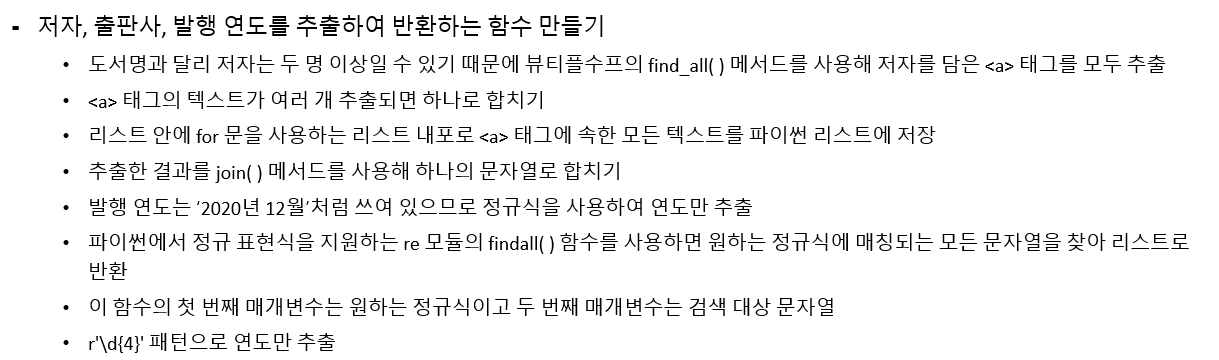

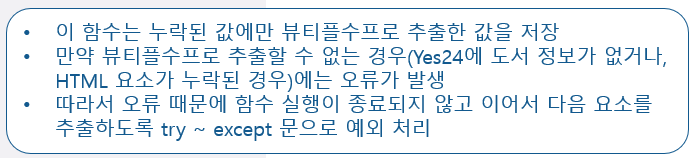

In [96]:
import re

def get_book_info(row):
    title = row['도서명']
    author = row['저자']
    pub = row['출판사']
    year = row['발행년도']
    # Yes24 도서 검색 페이지 URL
    url = 'http://www.yes24.com/Product/Search?domain=BOOK&query={}'
    # URL에 ISBN을 넣어 HTML 가져옵니다.
    r = requests.get(url.format(row['ISBN']))
    soup = BeautifulSoup(r.text, 'html.parser')   # HTML 파싱
    try:
        if pd.isna(title):
            # 클래스 이름이 'gd_name'인 a 태그의 텍스트를 가져옵니다.
            title = soup.find('a', attrs={'class':'gd_name'}) \
                    .get_text()
    except AttributeError:
        pass

    try:
        if pd.isna(author):
            # 클래스 이름이 'info_auth'인 span 태그 아래 a 태그의 텍스트를 가져옵니다.
            authors = soup.find('span', attrs={'class':'info_auth'}) \
                          .find_all('a')
            author_list = [auth.get_text() for auth in authors]
            author = ','.join(author_list)
    except AttributeError:
        pass

    try:
        if pd.isna(pub):
            # 클래스 이름이 'info_auth'인 span 태그 아래 a 태그의 텍스트를 가져옵니다.
            pub = soup.find('span', attrs={'class':'info_pub'}) \
                      .find('a') \
                      .get_text()
    except AttributeError:
        pass

    try:
        if year == -1:
            # 클래스 이름이 'info_date'인 span 태그 아래 텍스트를 가져옵니다.
            year_str = soup.find('span', attrs={'class':'info_date'}) \
                           .get_text()
            # 정규식으로 찾은 값 중에 첫 번째 것만 사용합니다.
            year = re.findall(r'\d{4}', year_str)[0]
    except AttributeError:
        pass

    return title, author, pub, year

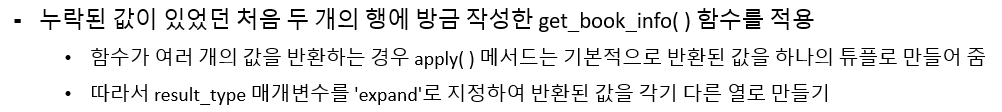

In [97]:
updated_sample = ns_book5[na_rows].head(2).apply(get_book_info,
    axis=1, result_type ='expand')
updated_sample

,0,1,2,3
3612,대한민국 국가지도집,국토교통부 국토지리정보원 [편],NaN,2019
3613,문재인 대통령 연설문집,대통령비서실 [편],NaN,2020


아래 코드 셀은 실행하는데 시간이 오래 걸립니다. 편의를 위해 실행한 결과를 저장해 놓은 CSV 파일을 사용하겠습니다.

In [83]:
# ns_book5_update = ns_book5[na_rows].apply(get_book_info,
#     axis=1, result_type ='expand')

# ns_book5_update.columns = ['도서명','저자','출판사','발행년도']
# ns_book5_update.head()

In [98]:
gdown.download('http://bit.ly/3UJZiHw', 'ns_book5_update.csv', quiet=False)

ns_book5_update = pd.read_csv('ns_book5_update.csv', index_col=0)
ns_book5_update.head()

Downloading...
From: http://bit.ly/3UJZiHw
To: /content/ns_book5_update.csv
100%|██████████| 406k/406k [00:00<00:00, 21.6MB/s]


,도서명,저자,출판사,발행년도
78,아산 정주영 레거시,김화진,서울대학교출판문화원,2021
265,골목의 시간을 그리다,정명섭.김효찬 지음,초록비책공방,2021
354,한국인의 맛,정명섭 지음,추수밭,2021
539,"한성부, 달 밝은 밤에",김이삭 지음,고즈넉이엔티,2021
607,100일 완성 마그마 러시아어 중고급 단어장,러포자 구제 연구소 외 지음,문예림,2021


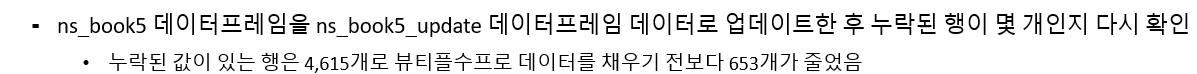

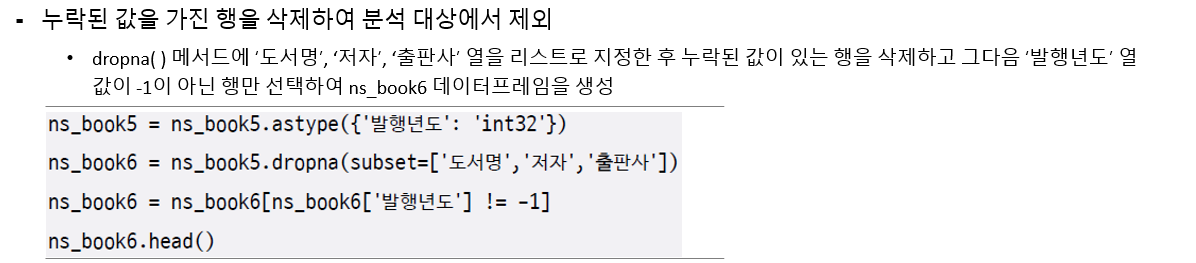

In [99]:
ns_book5.update(ns_book5_update)

na_rows = ns_book5['도서명'].isna() | ns_book5['저자'].isna() \
          | ns_book5['출판사'].isna() | ns_book5['발행년도'].eq(-1)
print(na_rows.sum())

4615


/tmp/ipykernel_25590/1890996919.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2021 2021 2021 ... 1996 1996 1995]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  ns_book5.update(ns_book5_update)


In [100]:
ns_book5 = ns_book5.astype({'발행년도': 'int32'})

In [101]:
ns_book6 = ns_book5.dropna(subset=['도서명','저자','출판사'])
ns_book6 = ns_book6[ns_book6['발행년도'] != -1]
ns_book6.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,,NaN,NaN,NaN,1,0,2021-03-19


In [102]:
ns_book6.to_csv('ns_book6.csv', index=False)

In [103]:
def data_fixing(ns_book4):
    """
    잘못된 값을 수정하거나 NaN 값을 채우는 함수

    :param ns_book4: data_cleaning() 함수에서 전처리된 데이터프레임
    """
    # 도서권수와 대출건수를 int32로 바꿉니다.
    ns_book4 = ns_book4.astype({'도서권수':'int32', '대출건수': 'int32'})
    # NaN인 세트 ISBN을 빈문자열로 바꿉니다.
    set_isbn_na_rows = ns_book4['세트 ISBN'].isna()
    ns_book4.loc[set_isbn_na_rows, '세트 ISBN'] = ''

    # 발행년도 열에서 연도 네 자리를 추출하여 대체합니다. 나머지 발행년도는 -1로 바꿉니다.
    ns_book5 = ns_book4.replace({'발행년도':'.*(\d{4}).*'}, r'\1', regex=True)
    unkown_year = ns_book5['발행년도'].str.contains('\D', na=True)
    ns_book5.loc[unkown_year, '발행년도'] = '-1'

    # 발행년도를 int32로 바꿉니다.
    ns_book5 = ns_book5.astype({'발행년도': 'int32'})
    # 4000년 이상인 경우 2333년을 뺍니다.
    dangun_yy_rows = ns_book5['발행년도'].gt(4000)
    ns_book5.loc[dangun_yy_rows, '발행년도'] = ns_book5.loc[dangun_yy_rows, '발행년도'] - 2333
    # 여전히 4000년 이상인 경우 -1로 바꿉니다.
    dangun_year = ns_book5['발행년도'].gt(4000)
    ns_book5.loc[dangun_year, '발행년도'] = -1
    # 0~1900년 사이의 발행년도는 -1로 바꿉니다.
    old_books = ns_book5['발행년도'].gt(0) & ns_book5['발행년도'].lt(1900)
    ns_book5.loc[old_books, '발행년도'] = -1

    # 도서명, 저자, 출판사가 NaN이거나 발행년도가 -1인 행을 찾습니다.
    na_rows = ns_book5['도서명'].isna() | ns_book5['저자'].isna() \
              | ns_book5['출판사'].isna() | ns_book5['발행년도'].eq(-1)
    # 교보문고 도서 상세 페이지에서 누락된 정보를 채웁니다.
    updated_sample = ns_book5[na_rows].apply(get_book_info,
        axis=1, result_type ='expand')
    updated_sample.columns = ['도서명','저자','출판사','발행년도']
    ns_book5.update(updated_sample)

    # 도서명, 저자, 출판사가 NaN이거나 발행년도가 -1인 행을 삭제합니다.
    ns_book6 = ns_book5.dropna(subset=['도서명','저자','출판사'])
    ns_book6 = ns_book6[ns_book6['발행년도'] != -1]

    return ns_book6

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_25590/3538836219.py:14: SyntaxWarning: invalid escape sequence '\d'
  ns_book5 = ns_book4.replace({'발행년도':'.*(\d{4}).*'}, r'\1', regex=True)
/tmp/ipykernel_25590/3538836219.py:15: SyntaxWarning: invalid escape sequence '\D'
  unkown_year = ns_book5['발행년도'].str.contains('\D', na=True)
